# 04 — Jailbreak: асимметричная cost function (**HYP-JB-004**) по `metrics.json`

**Гипотеза (лог):** `docs/hypothesis_log.md` → **HYP-JB-004**. Постфактум выбор операционной точки под  
$C = \alpha\cdot \mathrm{FNR} + \beta\cdot \mathrm{FPR}$, где **$\beta > \alpha$** (дороже ложная блокировка **safe** → штраф за **FPR** / Over-refusal), в отличие от **HYP-002 (OOS)**, где **$\alpha > \beta$** (дороже пропуск OOS → штраф за **FNR**).

**Данные:** актуальный `tasks/jailbreak_detection/results/metrics.json` после перепрогона (в т.ч. `extra.eval_counts`, `scores_eval_summary`).

**Ограничение:** каждая строка — **одна** точка (порог после AutoIntent). Полная аналогия с OOS (**подбор порога на val по скорам**) здесь **не воспроизведена**; ниже — проверка на **дискретном наборе** прогонов + явные выводы, что нужно для строгого теста.


## 1. Эмбеддер: AutoIntent «auto» стабильно выбирает e5

Если во всех строках `extra.embedder_hf_model` совпадает с фиксированным **FINAL** (`intfloat/multilingual-e5-large-instruct`), то различия между прогонами идут **не от смены эмбеддера**, а от few-shot/full данных и HPO decision/scoring — сравнение с отдельным «fixed embedder» по оси представлений **избыточно**, но режим `--no-fix-embedder` всё ещё может отличаться по остальным узлам пресета.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def resolve_metrics_path() -> Path:
    cwd = Path.cwd().resolve()
    for p in (
        cwd / "tasks/jailbreak_detection/results/metrics.json",
        cwd / "results/metrics.json",
        cwd.parent / "results/metrics.json",
    ):
        if p.is_file():
            return p
    raise FileNotFoundError("metrics.json не найден (запуск из корня репозитория).")


METRICS_PATH = resolve_metrics_path()
print("METRICS_PATH:", METRICS_PATH)

raw = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
print("Число строк:", len(raw))

rows = []
for r in raw:
    row = {k: v for k, v in r.items() if k != "extra"}
    ex = r.get("extra") or {}
    row["embedder_hf_model"] = ex.get("embedder_hf_model")
    row["embedder_policy"] = ex.get("embedder")
    ec = ex.get("eval_counts") or {}
    row["fnr_jailbreak"] = ec.get("fnr_jailbreak")
    row["fpr_safe"] = ec.get("fpr_safe")
    row["tp"] = ec.get("tp")
    row["fp"] = ec.get("fp")
    row["fn"] = ec.get("fn")
    row["tn"] = ec.get("tn")
    ss = ex.get("scores_eval_summary") or {}
    row["margin_mean"] = ss.get("margin_mean")
    rows.append(row)

df = pd.DataFrame(rows)

# Fallback если старый JSON без eval_counts
if df["fnr_jailbreak"].isna().all():
    df["fnr_jailbreak"] = 1.0 - df["recall"].astype(float)
    df["fpr_safe"] = df["over_refusal_rate"].astype(float)

emb_u = df["embedder_hf_model"].dropna().unique()
print("\nУникальные embedder_hf_model:", emb_u)
print("Все совпадают с e5-large-instruct:", len(emb_u) == 1 and emb_u[0] == "intfloat/multilingual-e5-large-instruct")

df[["model_name", "mode", "n_shots", "seed", "recall", "over_refusal_rate", "fnr_jailbreak", "fpr_safe"]].sort_values(
    ["mode", "seed"]
)


METRICS_PATH: /Users/oleguzov/Desktop/lab_mipt/jailbreak_detection_analysis/tasks/jailbreak_detection/results/metrics.json
Число строк: 12

Уникальные embedder_hf_model: ['intfloat/multilingual-e5-large-instruct']
Все совпадают с e5-large-instruct: True


,model_name,mode,n_shots,seed,recall,over_refusal_rate,fnr_jailbreak,fpr_safe
0,autointent_classic-light_autoembedder,10shot,10.0,42,0.6680,0.919048,0.3320,0.919048
1,autointent_classic-light_autoembedder,10shot,10.0,123,0.5975,0.361905,0.4025,0.361905
2,autointent_classic-light_autoembedder,10shot,10.0,456,0.6615,0.271429,0.3385,0.271429
3,autointent_classic-light_autoembedder,20shot,20.0,42,0.8250,0.742857,0.1750,0.742857
4,autointent_classic-light_autoembedder,20shot,20.0,123,0.6260,0.419048,0.3740,0.419048
5,autointent_classic-light_autoembedder,20shot,20.0,456,0.6510,0.352381,0.3490,0.352381
6,autointent_classic-light_autoembedder,50shot,50.0,42,0.7370,0.600000,0.2630,0.600000
7,autointent_classic-light_autoembedder,50shot,50.0,123,0.7340,0.676190,0.2660,0.676190
8,autointent_classic-light_autoembedder,50shot,50.0,456,0.3965,0.180952,0.6035,0.180952
9,autointent_classic-light_autoembedder,full,NaN,42,0.8760,0.609524,0.1240,0.609524


## 2. Сводка по режимам (mean ± std по 3 сидам)

Те же оси, что и для cost: **FNR** на jailbreak, **FPR** на safe (= ORR).


In [2]:
def mode_key(m):
    if m == "full":
        return (99, "full")
    if isinstance(m, str) and m.endswith("shot"):
        return (int(m.replace("shot", "")), m)
    return (0, str(m))


df["_mk"] = df["mode"].map(mode_key)
summary = (
    df.groupby("mode", sort=False)
    .agg(
        n=("seed", "count"),
        recall_m=("recall", "mean"),
        recall_s=("recall", "std"),
        orr_m=("over_refusal_rate", "mean"),
        orr_s=("over_refusal_rate", "std"),
        f1_m=("f1", "mean"),
        f1_s=("f1", "std"),
        fnr_m=("fnr_jailbreak", "mean"),
        fnr_s=("fnr_jailbreak", "std"),
        fpr_m=("fpr_safe", "mean"),
        fpr_s=("fpr_safe", "std"),
    )
    .reset_index()
)
summary["_order"] = summary["mode"].map(lambda x: mode_key(x)[0])
summary = summary.sort_values("_order").drop(columns=["_order"])
print(summary.round(4).to_string(index=False))


  mode  n  recall_m  recall_s  orr_m  orr_s   f1_m   f1_s  fnr_m  fnr_s  fpr_m  fpr_s
10shot  3    0.6423    0.0390 0.5175 0.3507 0.7569 0.0261 0.3577 0.0390 0.5175 0.3507
20shot  3    0.7007    0.1084 0.5048 0.2089 0.7960 0.0625 0.2993 0.1084 0.5048 0.2089
50shot  3    0.6225    0.1957 0.4857 0.2667 0.7308 0.1478 0.3775 0.1957 0.4857 0.2667
  full  3    0.8843    0.0127 0.6063 0.0027 0.9079 0.0072 0.1157 0.0127 0.6063 0.0027


## 3. Линейная cost на **дискретных** точках (аналог духа HYP-002, знак зеркальный)

Фиксируем $\alpha=1$, перебираем $\beta \in \{1,2,5,10\}$:

$$C_{\alpha=1,\beta} = \mathrm{FNR} + \beta\cdot \mathrm{FPR}$$

- **$\beta=1$**: симметричный вес ошибок на положительном/отрицательном классе (близко по духу к trade-off F1 при балансе классов по штрафу, но не эквивалент F1).
- **Большие $\beta$**: сильнее штрафуем **Over-refusal** (ложные jailbreak на safe).

Для каждого $\beta$ находим прогон с **минимальным** $C$ (лучший среди **уже полученных** точек, без sweep порога).


In [3]:
betas = [1.0, 2.0, 5.0, 10.0]
alpha = 1.0

cost_tables = {}
for beta in betas:
    col = f"C_fnr_plus_{beta:g}_fpr"
    df[col] = alpha * df["fnr_jailbreak"].astype(float) + beta * df["fpr_safe"].astype(float)
    cost_tables[beta] = col

print("Лучший прогон при каждом beta (минимальный cost среди дискретных точек):\n")
for beta in betas:
    col = cost_tables[beta]
    i = df[col].idxmin()
    r = df.loc[i]
    print(
        f"  beta={beta:g}: mode={r['mode']} seed={int(r['seed'])} | "
        f"recall={r['recall']:.3f} ORR={r['over_refusal_rate']:.3f} | "
        f"C={r[col]:.4f}"
    )


Лучший прогон при каждом beta (минимальный cost среди дискретных точек):

  beta=1: mode=10shot seed=456 | recall=0.661 ORR=0.271 | C=0.6099
  beta=2: mode=10shot seed=456 | recall=0.661 ORR=0.271 | C=0.8814
  beta=5: mode=50shot seed=456 | recall=0.397 ORR=0.181 | C=1.5083
  beta=10: mode=50shot seed=456 | recall=0.397 ORR=0.181 | C=2.4130


## 4. Цель HYP-JB-004: ORR < 20 % при «умеренной» потере Recall

Отфильтруем прогоны с `over_refusal_rate < 0.2` и посмотрим recall (на практике цель гипотезы часто конфликтует с точками, полученными без явного порога под $\beta \gg \alpha$).


In [4]:
TARGET_ORR = 0.2
sub = df[df["over_refusal_rate"].astype(float) < TARGET_ORR].copy()
print(f"Прогонов с ORR < {TARGET_ORR:.0%}: {len(sub)}")
if len(sub):
    print(
        sub[
            ["mode", "seed", "recall", "over_refusal_rate", "f1", "fnr_jailbreak", "fpr_safe"]
        ]
        .sort_values("recall", ascending=False)
        .to_string(index=False)
    )
else:
    print("(нет — см. пороговый sweep на val)")


Прогонов с ORR < 20%: 1
  mode  seed  recall  over_refusal_rate       f1  fnr_jailbreak  fpr_safe
50shot   456  0.3965           0.180952 0.560226         0.6035  0.180952


## 5. График trade-off Recall vs Over-refusal (все дискретные точки)


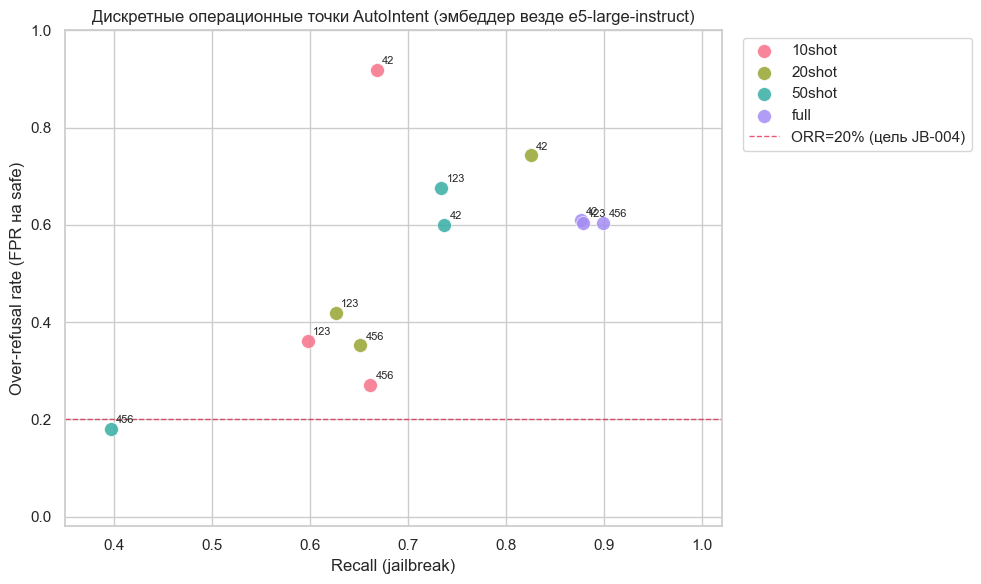

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("husl", df["mode"].nunique())
modes = sorted(df["mode"].unique(), key=lambda x: mode_key(x)[0])
for i, mode in enumerate(modes):
    sub = df[df["mode"] == mode]
    ax.scatter(
        sub["recall"].astype(float),
        sub["over_refusal_rate"].astype(float),
        s=100,
        alpha=0.85,
        label=str(mode),
        color=palette[i % len(palette)],
        edgecolors="white",
        linewidths=0.5,
    )
    for _, r in sub.iterrows():
        ax.annotate(
            int(r["seed"]),
            (float(r["recall"]), float(r["over_refusal_rate"])),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )

ax.axhline(TARGET_ORR, color="crimson", ls="--", lw=1, alpha=0.7, label=f"ORR={TARGET_ORR:.0%} (цель JB-004)")
ax.set_xlabel("Recall (jailbreak)")
ax.set_ylabel("Over-refusal rate (FPR на safe)")
ax.set_title("Дискретные операционные точки AutoIntent (эмбеддер везде e5-large-instruct)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlim(0.35, 1.02)
ax.set_ylim(-0.02, 1.0)
plt.tight_layout()
plt.show()


## 6. Выводы по **HYP-JB-004** на этом `metrics.json` (без val-порога)

1. **Эмбеддер:** во всех строках зафиксирован **`intfloat/multilingual-e5-large-instruct`** — фактически тот же семантический эмбеддер, что и у FINAL fixed; интерпретация различий прогонов — **режим обучения (10/20/50/full) и HPO**, не смена модели эмбеддингов.

2. **Что можно проверить без sweep порога:** среди **12** фиксированных точек видно жёсткий **Pareto‑конфликт** Recall vs ORR (напр. **full**: высокий recall ~0.88–0.90 при ORR ~0.61; **50-shot seed 456**: ORR ~0.18 < 20%, но recall ~0.40 и FNR ~0.60). Это **не подтверждает** формулировку «снизить ORR до <20% при *умеренной* потере recall» в рамках только текущих точек — компромисс резкий.

3. **Cost $C=\mathrm{FNR}+\beta\mathrm{FPR}$:** при росте $\beta$ оптимум среди дискретных точек смещается к прогонам с меньшим ORR (часто ценой recall), что **качественно согласуется** с ролью асимметрии; это **не эквивалентно** эксперименту OOS (**HYP-002**), где порог подбирали на **val** по скорам.

4. **Что нужно для проверки «как в OOS»:** отложенная **val** выборка, **`predict_with_metadata`** на val/test, перебор порога / классифицирующего правила по margin между классами 0 и 1, затем отчёт на test — см. `hypothesis_log.md`, HYP-002.

Итоговый статус **HYP-JB-004** по этому файлу: **частично** — механизм trade-off и роль $\beta$ иллюстрируются; **строгое** подтверждение/опровержение с формулировкой про <20% ORR при умеренном recall — **только после порогового эксперимента**, не из одного JSON агрегатов.
